In [291]:
# ============================================================
# 0. 라이브러리 설치
# ============================================================

# 처음 한 번만 실행
# !pip install Korpora tensorflow scikit-learn pandas numpy matplotlib

In [292]:
# ============================================================
# 1. 라이브러리 불러오기
# ============================================================
import random
import re
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

from datasets import load_dataset
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

# Tokenizer만 Keras에서 유지 (패딩용)
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [293]:
# ============================================================
# 2. 공통 설정값
# ============================================================

RANDOM_STATE = 42

# Tokenizer 관련
VOCAB_SIZE = 10000       # 사용할 최대 단어 수
MAX_LEN = 30             # 문장 최대 길이
OOV_TOKEN = "<OOV>"      # 사전에 없는 단어 처리 토큰

# 모델 구조 관련
EMBEDDING_DIM = 128      # 단어 임베딩 차원
HIDDEN_UNITS = 64        # RNN/LSTM/GRU hidden unit 수
DROPOUT_RATE = 0.3       # Dropout 비율

# 학습 관련
BATCH_SIZE = 64
EPOCHS = 10
LEARNING_RATE = 0.001

# 분류 클래스 수
NUM_CLASSES = 3

In [294]:
# ============================================================
# 3. Random Seed 고정
# ============================================================

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)          # ✅ PyTorch seed 추가
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(RANDOM_STATE)

In [295]:
# ============================================================
# 4. Korean Chatbot Data 로드
# ============================================================

dataset = load_dataset("didi0di/Chatbot_data_for_Korean_v1.0")

print(dataset)

# DataFrame 변환
df = pd.DataFrame(dataset["train"])

print(df.head())
print(df.info())
print(df["label"].value_counts())

DatasetDict({
    train: Dataset({
        features: ['Q', 'A', 'label'],
        num_rows: 11823
    })
})
                 Q            A  label
0           12시 땡!   하루가 또 가네요.      0
1      1지망 학교 떨어졌어    위로해 드립니다.      0
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0
4          PPL 심하네   눈살이 찌푸려지죠.      0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11823 entries, 0 to 11822
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   Q       11823 non-null  object
 1   A       11823 non-null  object
 2   label   11823 non-null  int64 
dtypes: int64(1), object(2)
memory usage: 277.2+ KB
None
label
0    5290
1    3570
2    2963
Name: count, dtype: int64


In [296]:
# ============================================================
# 5. 라벨 의미 확인
# ============================================================

label_map = {
    0: "일상다반사",
    1: "이별/부정",
    2: "사랑/긍정"
}

df["label_name"] = df["label"].map(label_map)

print(df[["Q", "A", "label", "label_name"]].head())
print(df["label_name"].value_counts())
print(df["label_name"].value_counts(normalize=True).round(3))

                 Q            A  label label_name
0           12시 땡!   하루가 또 가네요.      0      일상다반사
1      1지망 학교 떨어졌어    위로해 드립니다.      0      일상다반사
2     3박4일 놀러가고 싶다  여행은 언제나 좋죠.      0      일상다반사
3  3박4일 정도 놀러가고 싶다  여행은 언제나 좋죠.      0      일상다반사
4          PPL 심하네   눈살이 찌푸려지죠.      0      일상다반사
label_name
일상다반사    5290
이별/부정    3570
사랑/긍정    2963
Name: count, dtype: int64
label_name
일상다반사    0.447
이별/부정    0.302
사랑/긍정    0.251
Name: proportion, dtype: float64


In [297]:
# ============================================================
# 6. 텍스트 전처리 함수
# ============================================================

def clean_text(text):
    """
    Korean Chatbot Data용 간단 전처리 함수
    
    처리 내용:
    1. 문자열 변환
    2. 한글, 영어, 숫자, 공백만 남김
    3. 중복 공백 제거
    4. 앞뒤 공백 제거
    """
    text = str(text)
    
    # 한글, 영어, 숫자, 공백만 남김
    text = re.sub(r"[^가-힣a-zA-Z0-9\s]", " ", text)
    
    # 중복 공백 제거
    text = re.sub(r"\s+", " ", text)
    
    return text.strip()

In [298]:
# 전처리 적용
df["clean_text"] = df["Q"].apply(clean_text)

print(df[["Q", "clean_text", "label_name"]].head(10))

                         Q               clean_text label_name
0                   12시 땡!                    12시 땡      일상다반사
1              1지망 학교 떨어졌어              1지망 학교 떨어졌어      일상다반사
2             3박4일 놀러가고 싶다             3박4일 놀러가고 싶다      일상다반사
3          3박4일 정도 놀러가고 싶다          3박4일 정도 놀러가고 싶다      일상다반사
4                  PPL 심하네                  PPL 심하네      일상다반사
5                SD카드 망가졌어                SD카드 망가졌어      일상다반사
6                  SD카드 안돼                  SD카드 안돼      일상다반사
7           SNS 맞팔 왜 안하지ㅠㅠ             SNS 맞팔 왜 안하지      일상다반사
8  SNS 시간낭비인 거 아는데 매일 하는 중  SNS 시간낭비인 거 아는데 매일 하는 중      일상다반사
9        SNS 시간낭비인데 자꾸 보게됨        SNS 시간낭비인데 자꾸 보게됨      일상다반사


In [299]:
# ============================================================
# 7. 입력 X, 정답 y 설정
# ============================================================

X = df["clean_text"].values
y = df["label"].values

print(X[:5])
print(y[:5])

['12시 땡' '1지망 학교 떨어졌어' '3박4일 놀러가고 싶다' '3박4일 정도 놀러가고 싶다' 'PPL 심하네']
[0 0 0 0 0]


In [300]:
# ============================================================
# 8. Train / Validation / Test Split
# ============================================================

X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

X_valid, X_test, y_valid, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.5,
    random_state=RANDOM_STATE,
    stratify=y_temp
)

print("Train:", len(X_train))
print("Valid:", len(X_valid))
print("Test :", len(X_test))

Train: 9458
Valid: 1182
Test : 1183


In [301]:
# 라벨 분포 확인
for name, labels in {
    "train": y_train,
    "valid": y_valid,
    "test": y_test
}.items():
    print(f"\n[{name}]")
    print(pd.Series(labels).value_counts().sort_index())
    print(pd.Series(labels).value_counts(normalize=True).sort_index().round(3))


[train]
0    4232
1    2856
2    2370
Name: count, dtype: int64
0    0.447
1    0.302
2    0.251
Name: proportion, dtype: float64

[valid]
0    529
1    357
2    296
Name: count, dtype: int64
0    0.448
1    0.302
2    0.250
Name: proportion, dtype: float64

[test]
0    529
1    357
2    297
Name: count, dtype: int64
0    0.447
1    0.302
2    0.251
Name: proportion, dtype: float64


In [302]:
# ============================================================
# 9. Tokenizer 학습
# ============================================================

tokenizer = Tokenizer(
    num_words=VOCAB_SIZE,
    oov_token=OOV_TOKEN
)

# tokenizer는 train 데이터에만 fit
tokenizer.fit_on_texts(X_train)

print("전체 단어 수:", len(tokenizer.word_index))
print("상위 단어 예시:", list(tokenizer.word_index.items())[:20])

전체 단어 수: 11554
상위 단어 예시: [('<OOV>', 1), ('너무', 2), ('좋아하는', 3), ('싶어', 4), ('거', 5), ('같아', 6), ('안', 7), ('나', 8), ('좀', 9), ('사람', 10), ('내가', 11), ('어떻게', 12), ('싶다', 13), ('왜', 14), ('내', 15), ('썸', 16), ('사람이', 17), ('것', 18), ('없어', 19), ('이별', 20)]


In [303]:
# ============================================================
# 10. 정수 인코딩
# ============================================================

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_valid_seq = tokenizer.texts_to_sequences(X_valid)
X_test_seq = tokenizer.texts_to_sequences(X_test)

print(X_train_seq[:3])

[[3827, 61, 144], [3828, 9, 2083], [491, 277, 3829]]


In [304]:
# ============================================================
# 11. Padding
# ============================================================

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_valid_pad = pad_sequences(
    X_valid_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=MAX_LEN,
    padding="post",
    truncating="post"
)

print(X_train_pad.shape)
print(X_valid_pad.shape)
print(X_test_pad.shape)

(9458, 30)
(1182, 30)
(1183, 30)


In [305]:
# ============================================================
# 12. GRU 모델 생성 클래스
# ============================================================
import torch.nn as nn 
import torch
class TextGRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.dropout = nn.Dropout(0.3)
        self.gru = nn.GRU(
            input_size = embedding_dim,
            hidden_size = hidden_dim,
            num_layers = 1,
            batch_first = True,
        )
        self.fc = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, hidden = self.gru(embedded)
        out = self.dropout(hidden[-1])
        out = self.fc(out)
        return out
    
class TextBiGRU(nn.Module):
    def __init__(self, vocab_size, embedding_dim, hidden_dim, num_classes):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embedding_dim, padding_idx=0)
        self.dropout = nn.Dropout(0.3)
        self.bigru = nn.GRU(
            input_size = embedding_dim,
            hidden_size = hidden_dim,
            num_layers=2,
            batch_first = True,
            bidirectional = True,
            dropout = 0.3
        )
        self.fc = nn.Linear(hidden_dim * 2, num_classes)

    def forward(self, x):
        embedded = self.dropout(self.embedding(x))
        output, hidden = self.bigru(embedded)
        hidden = torch.cat((hidden[-2], hidden[-1]), dim=1)
        out = self.dropout(hidden)
        out = self.fc(out)
        return out


In [306]:
# ============================================================
# 13. GRU 모델 생성
# ============================================================

MODEL_TYPE = "gru"

torch.manual_seed(RANDOM_STATE)

model = TextGRU(
    vocab_size = VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_UNITS,
    num_classes=NUM_CLASSES
)

bimodel = TextBiGRU(
    vocab_size = VOCAB_SIZE,
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_UNITS,
    num_classes=NUM_CLASSES
)


In [307]:
# ============================================================
# 14. 모델 학습
# ============================================================
import time
import torch
from sklearn.utils.class_weight import compute_class_weight
from torch.utils.data import TensorDataset, DataLoader

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"device: {device}")

torch.manual_seed(RANDOM_STATE)
model = TextGRU(
    vocab_size=VOCAB_SIZE, embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_UNITS, num_classes=NUM_CLASSES
).to(device)
bimodel = TextBiGRU(
    vocab_size=VOCAB_SIZE, embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_UNITS, num_classes=NUM_CLASSES
).to(device)

class_weights = compute_class_weight(
    class_weight='balanced', classes=np.unique(y_train), y=y_train
)
class_weights = torch.tensor(class_weights, dtype=torch.float).to(device)
criterion = nn.CrossEntropyLoss(weight=class_weights)

optimizer    = torch.optim.Adam(model.parameters(),   lr=LEARNING_RATE)
bi_optimizer = torch.optim.Adam(bimodel.parameters(), lr=LEARNING_RATE)


x_tensor = torch.tensor(X_train_pad, dtype=torch.long)
y_tensor = torch.tensor(y_train,     dtype=torch.long)
loader   = DataLoader(TensorDataset(x_tensor, y_tensor), batch_size=BATCH_SIZE, shuffle=True)

# ── GRU 학습 ──────────────────────────────────────────────
gru_losses, gru_accs = [], []
model.train()
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_loss, epoch_acc, n = 0, 0, 0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(x_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        preds       = outputs.argmax(dim=1)
        epoch_loss += loss.item() * len(y_batch)
        epoch_acc  += (preds == y_batch).sum().item()
        n          += len(y_batch)
    gru_losses.append(epoch_loss / n)
    gru_accs.append(epoch_acc / n)
    print(f"[GRU]   Epoch {epoch+1:3d}/{EPOCHS}  Loss: {epoch_loss/n:.4f}  Acc: {epoch_acc/n:.4f}")

train_time = time.time() - start_time
print(f"GRU 학습 시간: {train_time:.2f}초\n")

# ── BiGRU 학습 ────────────────────────────────────────────
bigru_losses, bigru_accs = [], []
bimodel.train()
start_time = time.time()

for epoch in range(EPOCHS):
    epoch_loss, epoch_acc, n = 0, 0, 0
    for x_batch, y_batch in loader:
        x_batch, y_batch = x_batch.to(device), y_batch.to(device)
        bi_optimizer.zero_grad()
        outputs = bimodel(x_batch)
        loss    = criterion(outputs, y_batch)
        loss.backward()
        bi_optimizer.step()
        preds       = outputs.argmax(dim=1)
        epoch_loss += loss.item() * len(y_batch)
        epoch_acc  += (preds == y_batch).sum().item()
        n          += len(y_batch)
    bigru_losses.append(epoch_loss / n)
    bigru_accs.append(epoch_acc / n)
    print(f"[BiGRU] Epoch {epoch+1:3d}/{EPOCHS}  Loss: {epoch_loss/n:.4f}  Acc: {epoch_acc/n:.4f}")

print(f"BiGRU 학습 시간: {time.time() - start_time:.2f}초")

device: cuda
[GRU]   Epoch   1/10  Loss: 1.0996  Acc: 0.3587
[GRU]   Epoch   2/10  Loss: 0.9990  Acc: 0.4080
[GRU]   Epoch   3/10  Loss: 0.8759  Acc: 0.5336
[GRU]   Epoch   4/10  Loss: 0.7876  Acc: 0.6188
[GRU]   Epoch   5/10  Loss: 0.7089  Acc: 0.6791
[GRU]   Epoch   6/10  Loss: 0.6499  Acc: 0.7191
[GRU]   Epoch   7/10  Loss: 0.5945  Acc: 0.7499
[GRU]   Epoch   8/10  Loss: 0.5560  Acc: 0.7699
[GRU]   Epoch   9/10  Loss: 0.5101  Acc: 0.7946
[GRU]   Epoch  10/10  Loss: 0.4714  Acc: 0.8091
GRU 학습 시간: 2.43초

[BiGRU] Epoch   1/10  Loss: 0.9872  Acc: 0.4826
[BiGRU] Epoch   2/10  Loss: 0.8312  Acc: 0.6032
[BiGRU] Epoch   3/10  Loss: 0.7272  Acc: 0.6715
[BiGRU] Epoch   4/10  Loss: 0.6388  Acc: 0.7215
[BiGRU] Epoch   5/10  Loss: 0.5679  Acc: 0.7626
[BiGRU] Epoch   6/10  Loss: 0.5098  Acc: 0.7950
[BiGRU] Epoch   7/10  Loss: 0.4496  Acc: 0.8166
[BiGRU] Epoch   8/10  Loss: 0.4167  Acc: 0.8277
[BiGRU] Epoch   9/10  Loss: 0.3830  Acc: 0.8481
[BiGRU] Epoch  10/10  Loss: 0.3441  Acc: 0.8637
BiGRU 학습 

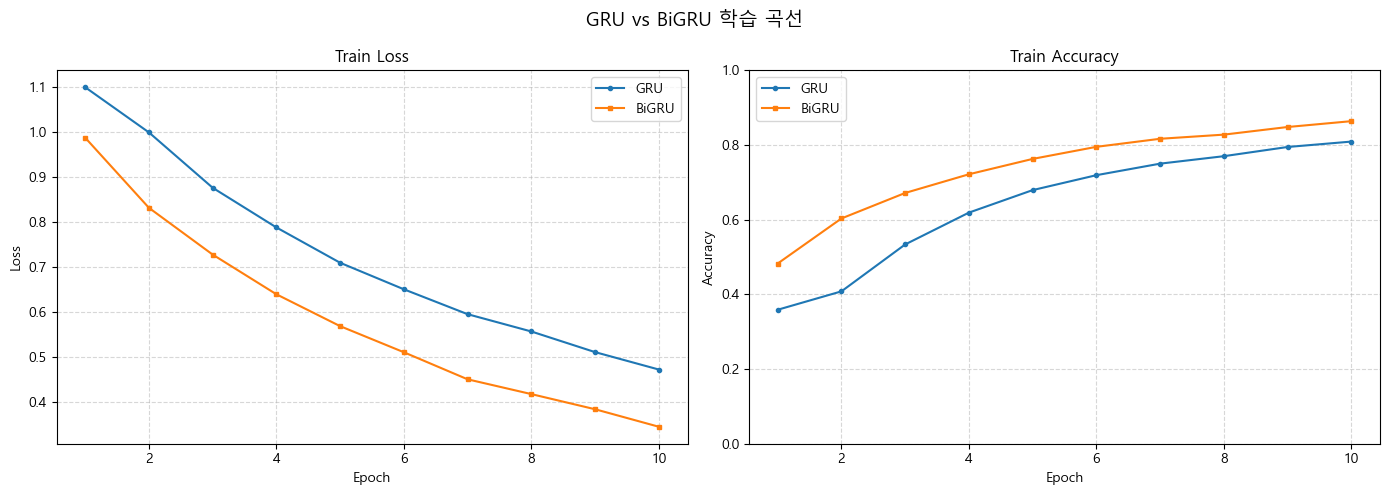

In [308]:
# ============================================================
# 15. 학습 곡선 시각화
# ============================================================

plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

epochs_range = range(1, EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss 그래프
axes[0].plot(epochs_range, gru_losses,   label="GRU",   marker='o', markersize=3, linewidth=1.5)
axes[0].plot(epochs_range, bigru_losses, label="BiGRU", marker='s', markersize=3, linewidth=1.5)
axes[0].set_title("Train Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()
axes[0].grid(True, linestyle='--', alpha=0.5)

# Accuracy 그래프
axes[1].plot(epochs_range, gru_accs,   label="GRU",   marker='o', markersize=3, linewidth=1.5)
axes[1].plot(epochs_range, bigru_accs, label="BiGRU", marker='s', markersize=3, linewidth=1.5)
axes[1].set_title("Train Accuracy")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_ylim(0, 1)     
axes[1].legend()
axes[1].grid(True, linestyle='--', alpha=0.5)

fig.suptitle("GRU vs BiGRU 학습 곡선", fontsize=14)
plt.tight_layout()
plt.show()

In [309]:
# 그래디언트 크기 확인
optimizer.zero_grad()
outputs = model(x_batch)
loss = criterion(outputs, y_batch)
loss.backward()

for name, param in model.named_parameters():
    if param.grad is not None:
        print(f"{name}: grad_norm = {param.grad.norm().item():.6f}")

embedding.weight: grad_norm = 0.133330
gru.weight_ih_l0: grad_norm = 1.100916
gru.weight_hh_l0: grad_norm = 0.430369
gru.bias_ih_l0: grad_norm = 0.429053
gru.bias_hh_l0: grad_norm = 0.240184
fc.weight: grad_norm = 0.194496
fc.bias: grad_norm = 0.074658


In [310]:
# ============================================================
# 16. Test 평가
# ============================================================
model.eval()
bimodel.eval()

x_test = torch.tensor(X_test_pad, dtype=torch.long).to(device)

with torch.no_grad():
    gru_pred   = model(x_test).argmax(dim=1).cpu().numpy()
    bigru_pred = bimodel(x_test).argmax(dim=1).cpu().numpy()

print("=== GRU ===")
print(f"Accuracy   : {accuracy_score(y_test, gru_pred):.4f}")
print(f"Macro F1   : {f1_score(y_test, gru_pred, average='macro'):.4f}")
print()
print("=== BiGRU ===")
print(f"Accuracy   : {accuracy_score(y_test, bigru_pred):.4f}")
print(f"Macro F1   : {f1_score(y_test, bigru_pred, average='macro'):.4f}")

=== GRU ===
Accuracy   : 0.7219
Macro F1   : 0.7275

=== BiGRU ===
Accuracy   : 0.7430
Macro F1   : 0.7452


In [314]:
# ============================================================
# 17. Classification Report
# ============================================================

target_names = ["일상다반사", "이별/부정", "사랑/긍정"]

print(classification_report(
    y_test,
    gru_pred,
    target_names=target_names
))

print(classification_report(
    y_test,
    bigru_pred,
    target_names=target_names
))

              precision    recall  f1-score   support

       일상다반사       0.74      0.70      0.72       529
       이별/부정       0.64      0.74      0.68       357
       사랑/긍정       0.82      0.75      0.78       297

    accuracy                           0.72      1183
   macro avg       0.73      0.73      0.73      1183
weighted avg       0.73      0.72      0.72      1183

              precision    recall  f1-score   support

       일상다반사       0.81      0.71      0.75       529
       이별/부정       0.63      0.82      0.71       357
       사랑/긍정       0.83      0.71      0.77       297

    accuracy                           0.74      1183
   macro avg       0.76      0.75      0.75      1183
weighted avg       0.76      0.74      0.75      1183



In [317]:
# ============================================================
# 18. Confusion Matrix
# ============================================================

cm = confusion_matrix(y_test, gru_pred)

cm_df = pd.DataFrame(
    cm,
    index=["True_일상", "True_이별", "True_사랑"],
    columns=["Pred_일상", "Pred_이별", "Pred_사랑"]
)

bicm = confusion_matrix(y_test, bigru_pred)

cm_bidf = pd.DataFrame(
    bicm,
    index=["True_일상", "True_이별", "True_사랑"],
    columns=["Pred_일상", "Pred_이별", "Pred_사랑"]
)

print(cm_df)
print(cm_bidf)

         Pred_일상  Pred_이별  Pred_사랑
True_일상      369      125       35
True_이별       79      263       15
True_사랑       52       23      222
         Pred_일상  Pred_이별  Pred_사랑
True_일상      374      128       27
True_이별       49      293       15
True_사랑       39       46      212


In [319]:
# ============================================================
# 19. 결과 정리
# ============================================================

result = {
    "model": "GRU",
    "accuracy": f'{accuracy_score(y_test, gru_pred):.4f}',
    "macro_f1": f"{f1_score(y_test, gru_pred, average='macro'):.4f}",
    "weighted_f1": f"{f1_score(y_test, gru_pred, average='weighted'):.4f}",
    "train_time_sec": train_time,
    "vocab_size": VOCAB_SIZE,
    "max_len": MAX_LEN,
    "embedding_dim": EMBEDDING_DIM,
    "hidden_units": HIDDEN_UNITS,
    "dropout": DROPOUT_RATE,
    "batch_size": BATCH_SIZE,
    "epochs": EPOCHS,
    "optimizer": "Adam",
    "loss": "sparse_categorical_crossentropy",
    "random_state": RANDOM_STATE
}

result_df = pd.DataFrame([result])
result_df

,model,accuracy,macro_f1,weighted_f1,train_time_sec,vocab_size,max_len,embedding_dim,hidden_units,dropout,batch_size,epochs,optimizer,loss,random_state
0,GRU,0.7219,0.7275,0.7233,2.433507,10000,30,128,64,0.3,64,10,Adam,sparse_categorical_crossentropy,42
